# AI Data Centers & Residential Electricity Prices
Phase 2: Data wrangling, dataset description, preliminary statistical analysis, and ML modeling.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

## 2. Build the treatment group (counties with AI data centers)
Load data center locations, filter to active US facilities, aggregate to county level, and pull residential electricity prices (2018-2024) from EIA-861.

In [2]:
# Reading AI Datacenter locations, filtering out to get active datacenters
datacenters = pd.read_csv('ai_data_centers_consumption_and_locations.csv')

datacenters = datacenters[(datacenters['Country']=='United States') & (datacenters['Current power (MW)'] > 0)]
datacenters['State'] = datacenters['County'].str.split(', ').str[1]
datacenters['County'] = datacenters['County'].str.split(',').str[0]
datacenters.drop(columns = ['Current H100 equivalents',
                            'Current total capital cost (2025 USD billions)',
                            'Owner', 'Users', 'Selected Sources', 'Calculations sheet',
                            'Project', 'Current chip types', 'All chip types', 'Investors',
                            'Construction companies', 'Energy companies', 'Country','Address'], inplace = True)

datacenters_by_county = datacenters.groupby(['County','State']).agg(
    num_datacenters = ('Current power (MW)', 'count'),
    total_power_consumption_mw = ('Current power (MW)', 'sum')
    )
datacenters_by_county = datacenters_by_county.reset_index()
datacenters_by_county['County'] = datacenters_by_county['County'].str.replace(' County', '').str.strip()

# per relavent county, find utility number id
county_to_utility = pd.read_excel('eia861/f8612024/Service_Territory_2024.xlsx', sheet_name='Counties_States')[['State', 'County', 'Utility Number']].drop_duplicates()
county_to_utility['State'] = county_to_utility['State'].str.strip()
county_to_utility['County'] = county_to_utility['County'].str.strip()
df_master = datacenters_by_county.merge(county_to_utility, on=['State', 'County'], how='left')

# loop through past 7 years and obtain residential rates per county using EIA861
year_range = range(2018, 2025)
price_columns = []
for year in year_range:
    file_path = f'eia861/f861{year}/Sales_Ult_Cust_{year}.xlsx'
    df_sales = pd.read_excel(file_path, sheet_name='States', header=2)

    # calculate the residential price, keep only prices associated with physical infrastructure
    df_sales['Megawatthours'] = pd.to_numeric(df_sales['Megawatthours'], errors='coerce')
    df_sales['Thousand Dollars'] = pd.to_numeric(df_sales['Thousand Dollars'], errors='coerce')
    df_sales = df_sales[df_sales['Part'].isin(['A', 'C']) & (df_sales['Megawatthours'] > 0)].copy()
    price_col = f'Price_{year}_MWh'
    price_columns.append(price_col)
    df_sales[price_col] = (df_sales['Thousand Dollars'] * 1000) / df_sales['Megawatthours']
    
    # Average the price per utility provider and put back into df_master
    utility_prices = df_sales.groupby(['Utility Number', 'State'])[price_col].mean().reset_index()
    df_master = df_master.merge(utility_prices, on=['Utility Number', 'State'], how='left')

# recreate final dataframe, averaging utilities providing the same county in the same year
final_treatment_group = (df_master
                         .groupby(['County', 'State', 'num_datacenters', 'total_power_consumption_mw'])[price_columns]
                         .mean()
                         .reset_index()
                         .sort_values(by=['num_datacenters', 'total_power_consumption_mw'], ascending=[False, False]))

# final_treatment_group

## 3. Dataset description: raw sources
Size, columns, and basic structure of each raw dataset before wrangling.

In [3]:
print("=== ai_data_centers_consumption_and_locations.csv (raw) ===")
dc_raw = pd.read_csv('ai_data_centers_consumption_and_locations.csv')
print("Shape:", dc_raw.shape)
print("Columns:", dc_raw.columns.tolist())
print()

print("=== EIA-861 Sales_Ult_Cust_2024.xlsx, States sheet (raw) ===")
sales_raw = pd.read_excel('eia861/f8612024/Sales_Ult_Cust_2024.xlsx', sheet_name='States', header=2)
print("Shape:", sales_raw.shape)
print("Columns:", sales_raw.columns.tolist())
print()

print("=== final_treatment_group (after wrangling) ===")
print("Shape:", final_treatment_group.shape)
print(final_treatment_group.head())


=== ai_data_centers_consumption_and_locations.csv (raw) ===
Shape: (86, 17)
Columns: ['Name', 'Current H100 equivalents', 'Current power (MW)', 'Current total capital cost (2025 USD billions)', 'Owner', 'Users', 'Selected Sources', 'Calculations sheet', 'Project', 'Current chip types', 'All chip types', 'Investors', 'Construction companies', 'Energy companies', 'Country', 'Address', 'County']

=== EIA-861 Sales_Ult_Cust_2024.xlsx, States sheet (raw) ===


Shape: (2816, 24)
Columns: ['Data Year', 'Utility Number', 'Utility Name', 'Part', 'Service Type', 'Data Type\nO = Observed\nI = Imputed', 'State', 'Ownership', 'BA Code', 'Thousand Dollars', 'Megawatthours', 'Count', 'Thousand Dollars.1', 'Megawatthours.1', 'Count.1', 'Thousand Dollars.2', 'Megawatthours.2', 'Count.2', 'Thousand Dollars.3', 'Megawatthours.3', 'Count.3', 'Thousand Dollars.4', 'Megawatthours.4', 'Count.4']

=== final_treatment_group (after wrangling) ===
Shape: (46, 11)
      County State  num_datacenters  total_power_consumption_mw  \
23   Licking    OH                3                      1108.0   
20   Henrico    VA                3                       562.0   
27  Maricopa    AZ                3                       449.0   
2      Bexar    TX                3                       154.0   
35    Shelby    TN                2                      1286.0   

    Price_2018_MWh  Price_2019_MWh  Price_2020_MWh  Price_2021_MWh  \
23      120.697184      122.216094  

## 4. Load Census demographics and build the control group
Pull population and median household income by county (USDA ERS / Census data), then isolate counties with **zero** data center presence to serve as the control group, matched on the same geographic key.

In [4]:
# 1. Load Census / USDA ERS Datasets
pop_df = pd.read_csv('census_data/PopulationEstimates.csv', encoding='latin1')
inc_df = pd.read_csv('census_data/Unemployment2023.csv', encoding='latin1')

# 2. Extract Population (2021) and Median Household Income (2022)
pop_sub = pop_df[pop_df['Attribute'] == 'POP_ESTIMATE_2021'][['FIPStxt', 'State', 'Area_Name', 'Value']].copy()
pop_sub.rename(columns={'FIPStxt': 'FIPS', 'Value': 'Population_2021'}, inplace=True)
pop_sub['Population_2021'] = pd.to_numeric(pop_sub['Population_2021'].astype(str).str.replace(',', ''), errors='coerce')

inc_sub = inc_df[inc_df['Attribute'] == 'Median_Household_Income_2022'][['FIPS_Code', 'State', 'Area_Name', 'Value']].copy()
inc_sub.rename(columns={'FIPS_Code': 'FIPS', 'Value': 'Median_Income_2022'}, inplace=True)
inc_sub['Median_Income_2022'] = pd.to_numeric(inc_sub['Median_Income_2022'].astype(str).str.replace(',', ''), errors='coerce')

# Merge Census stats together
census_merged = pop_sub.merge(inc_sub[['FIPS', 'Median_Income_2022']], on='FIPS', how='inner')
census_merged['County'] = census_merged['Area_Name'].str.replace(' County', '').str.replace(r',\s*[A-Z]{2}', '', regex=True).str.strip()
census_merged['State'] = census_merged['State'].str.strip()

# 3. Isolate Control Counties (Exclude counties present in final_treatment_group)
treated_counties = final_treatment_group[['State', 'County']].drop_duplicates()
treated_counties['Is_Treatment'] = True

control_pool = census_merged.merge(treated_counties, on=['State', 'County'], how='left')
control_pool = control_pool[control_pool['Is_Treatment'].isna()].copy()

# This is your clean dataframe of control counties with matching statistics!
control_demographics = control_pool[['County', 'State', 'Population_2021', 'Median_Income_2022']].dropna()
control_demographics

,County,State,Population_2021,Median_Income_2022
0,United States,US,332048977.0,74755.0
1,Alabama,AL,5050380.0,59703.0
2,Autauga,AL,59203.0,70148.0
3,Baldwin,AL,239439.0,71704.0
4,Barbour,AL,24533.0,41151.0
...,...,...,...,...
3190,Sweetwater,WY,41626.0,75779.0
3191,Teton,WY,23605.0,127677.0
3192,Uinta,WY,20681.0,73072.0
3193,Washakie,WY,7719.0,60699.0


### Dataset description: Census sources

In [5]:
print("=== PopulationEstimates.csv (raw) ===")
print("Shape:", pop_df.shape)
print("Columns:", pop_df.columns.tolist())
print()

print("=== Unemployment2023.csv (raw) ===")
print("Shape:", inc_df.shape)
print("Columns:", inc_df.columns.tolist())
print()

print("=== census_merged (after wrangling) ===")
print("Shape:", census_merged.shape)
print()

print("=== control_demographics (candidate control counties) ===")
print("Shape:", control_demographics.shape)
print(control_demographics.head())


=== PopulationEstimates.csv (raw) ===
Shape: (208225, 5)
Columns: ['FIPStxt', 'State', 'Area_Name', 'Attribute', 'Value']

=== Unemployment2023.csv (raw) ===
Shape: (329726, 5)
Columns: ['FIPS_Code', 'State', 'Area_Name', 'Attribute', 'Value']

=== census_merged (after wrangling) ===
Shape: (3195, 6)

=== control_demographics (candidate control counties) ===
Shape: (3148, 4)
          County State  Population_2021  Median_Income_2022
0  United States    US      332048977.0             74755.0
1        Alabama    AL        5050380.0             59703.0
2        Autauga    AL          59203.0             70148.0
3        Baldwin    AL         239439.0             71704.0
4        Barbour    AL          24533.0             41151.0


## 5. Build the full treatment vs. control panel
Merge the true statewide baseline growth rate, attach control-county prices for 2018-2024, and concatenate treatment + control into one panel.

In [6]:
# load full state/county service territory mapping for true state-demeaning baseline
full_counties = pd.read_excel('eia861/f8612024/Service_Territory_2024.xlsx', sheet_name='Counties_States')[['State', 'County', 'Utility Number']].drop_duplicates()
full_counties['State'] = full_counties['State'].str.strip()
full_counties['County'] = full_counties['County'].str.strip()

# helper to calculate residential prices per utility for any year
def get_utility_prices(year):
    df = pd.read_excel(f'eia861/f861{year}/Sales_Ult_Cust_{year}.xlsx', sheet_name='States', header=2)
    df['Megawatthours'] = pd.to_numeric(df['Megawatthours'], errors='coerce')
    df['Thousand Dollars'] = pd.to_numeric(df['Thousand Dollars'], errors='coerce')
    df = df[df['Part'].isin(['A', 'C']) & (df['Megawatthours'] > 0)].copy()
    col = f'Price_{year}_MWh'
    df[col] = (df['Thousand Dollars'] * 1000) / df['Megawatthours']
    return df.groupby(['Utility Number', 'State'])[col].mean().reset_index()

# compute true statewide growth mean using all counties across 2018 and 2024
fp = full_counties.merge(get_utility_prices(2018), on=['Utility Number', 'State'], how='left')
fp = fp.merge(get_utility_prices(2024), on=['Utility Number', 'State'], how='left')
fp['Growth'] = ((fp['Price_2024_MWh'] - fp['Price_2018_MWh']) / fp['Price_2018_MWh']) * 100
state_means = fp.groupby('State')['Growth'].mean().reset_index().rename(columns={'Growth': 'True_State_Mean_Growth'})

# merge true state mean back into final treatment group
final_treatment_group = final_treatment_group.merge(state_means, on='State', how='left')

# build control_final using matched controls
control_final = control_demographics.merge(county_to_utility, on=['State', 'County'], how='inner').drop_duplicates(subset=['County', 'State'])
control_final['num_datacenters'] = 0
control_final['total_power_consumption_mw'] = 0
control_final['Treatment_Tier'] = 'Control (0 MW)'

# loop to pull control prices across 2018-2024
for year in range(2018, 2025):
    control_final = control_final.merge(get_utility_prices(year), on=['Utility Number', 'State'], how='left')

# concatenate treatment and control into one universal dataframe
universal_panel = pd.concat([final_treatment_group, control_final], ignore_index=True)

# calculate growth metrics and universal state demeaning
universal_panel['Price_Growth_Pct'] = ((universal_panel['Price_2024_MWh'] - universal_panel['Price_2018_MWh']) / universal_panel['Price_2018_MWh']) * 100
universal_panel['True_State_Demeaned_Growth'] = universal_panel['Price_Growth_Pct'] - universal_panel.groupby('State')['Price_Growth_Pct'].transform('mean')

## 6. Data wrangling checks
Missing data, duplicates, and range/format checks on the final panel.

In [7]:
print("=== Missing data by column (universal_panel) ===")
print(universal_panel.isna().sum())
print()

print("Duplicate (County, State) rows:", universal_panel.duplicated(subset=['County','State']).sum())
print()

# Range check: prices should be positive
bad_prices = universal_panel[[c for c in universal_panel.columns if c.startswith('Price_')]].lt(0).any().any()
print("Any negative prices found:", bad_prices)
print()

print("NOTE: Most missing values are in the control group's price columns, where a county's")
print("utility could not be matched to an EIA-861 price record for that year (e.g. municipal")
print("or cooperative utilities not filed under Parts A/C). These rows are dropped before")
print("correlation/regression, not imputed, since price is our core outcome variable and")
print("imputing it risks manufacturing a false signal.")

# Drop rows missing the core outcome variable for downstream analysis
universal_panel_clean = universal_panel.dropna(subset=['Price_2018_MWh','Price_2024_MWh']).copy()
print()
print("Rows remaining after dropping missing-price rows:", universal_panel_clean.shape[0])


=== Missing data by column (universal_panel) ===
County                           0
State                            0
num_datacenters                  0
total_power_consumption_mw       0
Price_2018_MWh                 467
Price_2019_MWh                 151
Price_2020_MWh                 876
Price_2021_MWh                 876
Price_2022_MWh                 876
Price_2023_MWh                 860
Price_2024_MWh                 857
True_State_Mean_Growth        2929
Population_2021                 46
Median_Income_2022              46
Utility Number                  46
Treatment_Tier                  46
Price_Growth_Pct               859
True_State_Demeaned_Growth     859
dtype: int64

Duplicate (County, State) rows: 0

Any negative prices found: True

NOTE: Most missing values are in the control group's price columns, where a county's
utility could not be matched to an EIA-861 price record for that year (e.g. municipal
or cooperative utilities not filed under Parts A/C). These rows are 

## 7. Preliminary statistical analysis
Pearson correlation coefficient between data center power consumption and state-demeaned residential price growth, plus a comparison of linear/quadratic/cubic fit.

In [8]:
from scipy import stats

final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh'])
    / final_treatment_group['Price_2018_MWh']
) * 100
final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] - final_treatment_group['True_State_Mean_Growth']
)
plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'total_power_consumption_mw'])

r_linear, p_linear = stats.pearsonr(plot_df['total_power_consumption_mw'], plot_df['Growth_Demeaned'])
print(f"Pearson r (MW vs demeaned price growth): {r_linear:.4f}, p-value: {p_linear:.4f}, n={len(plot_df)}")

plot_df['Log_MW'] = np.log1p(plot_df['total_power_consumption_mw'])
r_log, p_log = stats.pearsonr(plot_df['Log_MW'], plot_df['Growth_Demeaned'])
print(f"Pearson r (log(MW) vs demeaned price growth): {r_log:.4f}, p-value: {p_log:.4f}")
print()

x = plot_df['total_power_consumption_mw'].values
y = plot_df['Growth_Demeaned'].values
for deg, name in [(1, 'Linear'), (2, 'Quadratic'), (3, 'Cubic')]:
    coeffs = np.polyfit(x, y, deg)
    yhat = np.polyval(coeffs, x)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"{name} fit R^2: {r2:.4f}")


Pearson r (MW vs demeaned price growth): 0.2149, p-value: 0.1563, n=45
Pearson r (log(MW) vs demeaned price growth): 0.2917, p-value: 0.0519

Linear fit R^2: 0.0462
Quadratic fit R^2: 0.0638
Cubic fit R^2: 0.1067


**Interpretation:** the correlation is positive but weak (r &approx; 0.21-0.29) and only borderline
significant at the log-transformed scale (p &approx; 0.05). R&sup2; stays low (0.05-0.11) across
linear, quadratic, and cubic fits, so a straight line is a reasonable, defensible choice - a
higher-order polynomial doesn't meaningfully improve fit. This means we cannot yet reject H0
outright, but there is a modest positive signal consistent with H1 that's worth testing further
with a larger/more recent panel (e.g. 2023-2026 data center growth specifically, rather than the
full 2018-2024 window).

## 8. Visualization: linear scale

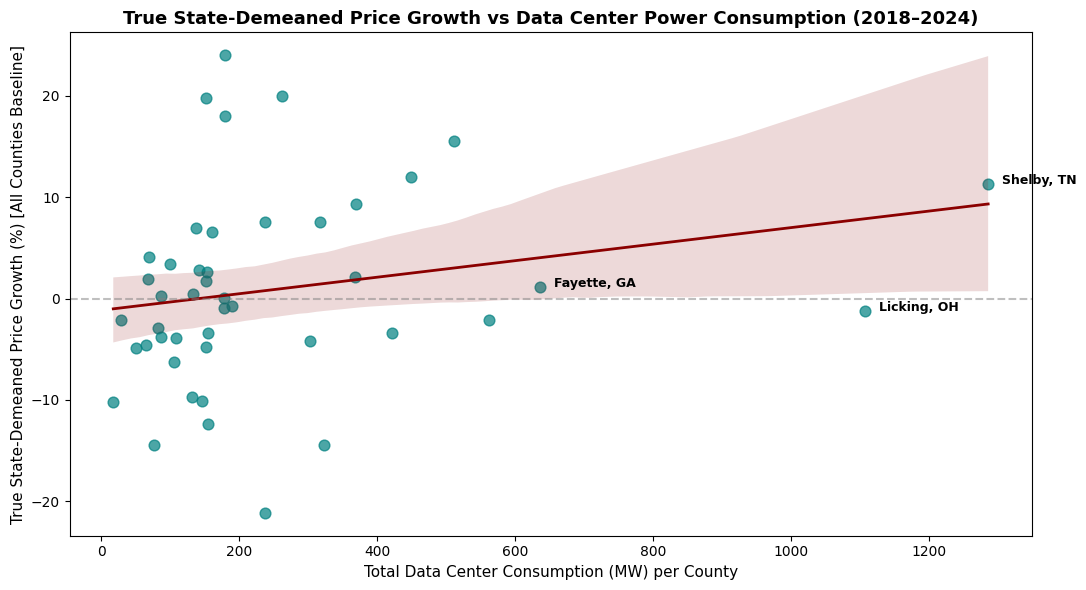

In [9]:
#TREATING LINEARLY

final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh']) 
    / final_treatment_group['Price_2018_MWh']
) * 100

# 2. Demean the price growth relative to true statewide averages (all counties)
final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] 
    - final_treatment_group['True_State_Mean_Growth']
)

# Filter missing values
plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'total_power_consumption_mw'])

# Generate linear regression scatter plot
plt.figure(figsize=(11, 6))
sns.regplot(
    data=plot_df, 
    x='total_power_consumption_mw', 
    y='Growth_Demeaned', 
    scatter_kws={'alpha': 0.7, 'color': 'teal', 's': 60}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('True State-Demeaned Price Growth vs Data Center Power Consumption (2018–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Total Data Center Consumption (MW) per County', fontsize=11)
plt.ylabel('True State-Demeaned Price Growth (%) [All Counties Baseline]', fontsize=11)

# Label the top 3 highest-consumption counties directly on the plot
top_counties = plot_df.nlargest(3, 'total_power_consumption_mw')
for _, row in top_counties.iterrows():
    plt.text(
        row['total_power_consumption_mw'] + 20, 
        row['Growth_Demeaned'], 
        f"{row['County']}, {row['State']}", 
        fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()

## 9. Visualization: log-transformed scale
Applied since MW consumption is right-skewed (a few very large data centers dominate the raw scale).

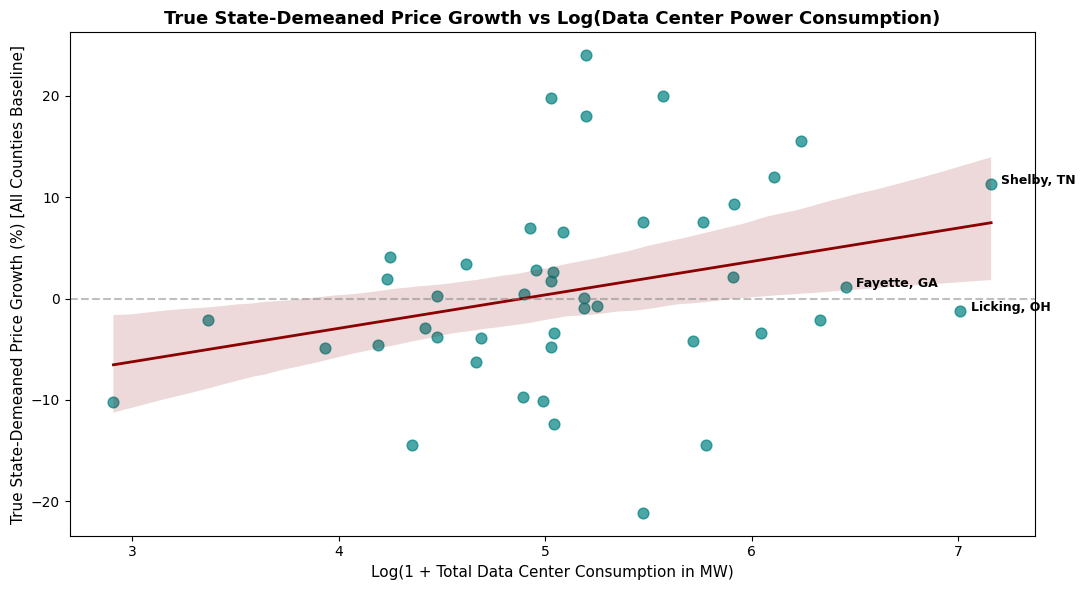

In [10]:
#TREATING X LOGARITHMICALLY

final_treatment_group['Price_Growth_Pct'] = (
    (final_treatment_group['Price_2024_MWh'] - final_treatment_group['Price_2018_MWh']) 
    / final_treatment_group['Price_2018_MWh']
) * 100

# Demean using true statewide average from all counties
final_treatment_group['Growth_Demeaned'] = (
    final_treatment_group['Price_Growth_Pct'] 
    - final_treatment_group['True_State_Mean_Growth']
)

# applying log transform to x axis due to right skewing
final_treatment_group['Log_MW'] = np.log1p(final_treatment_group['total_power_consumption_mw'])

plot_df = final_treatment_group.dropna(subset=['Growth_Demeaned', 'Log_MW'])

plt.figure(figsize=(11, 6))
sns.regplot(
    data=plot_df, 
    x='Log_MW', 
    y='Growth_Demeaned', 
    scatter_kws={'alpha': 0.7, 'color': 'teal', 's': 60}, 
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('True State-Demeaned Price Growth vs Log(Data Center Power Consumption)', fontsize=13, fontweight='bold')
plt.xlabel('Log(1 + Total Data Center Consumption in MW)', fontsize=11)
plt.ylabel('True State-Demeaned Price Growth (%) [All Counties Baseline]', fontsize=11)

top_counties = plot_df.nlargest(3, 'Log_MW')
for _, row in top_counties.iterrows():
    plt.text(
        row['Log_MW'] + 0.05, 
        row['Growth_Demeaned'], 
        f"{row['County']}, {row['State']}", 
        fontsize=9, weight='bold'
    )

plt.tight_layout()
plt.show()

## 10. Final panel preview

In [11]:
final_treatment_group

,County,State,num_datacenters,total_power_consumption_mw,Price_2018_MWh,Price_2019_MWh,Price_2020_MWh,Price_2021_MWh,Price_2022_MWh,Price_2023_MWh,Price_2024_MWh,True_State_Mean_Growth,Price_Growth_Pct,Growth_Demeaned,Log_MW
0,Licking,OH,3,1108.00000,120.697184,122.216094,123.445555,129.365480,135.792983,144.718781,153.825718,28.654130,27.447644,-1.206486,7.011214
1,Henrico,VA,3,562.00000,116.616409,120.564580,121.796104,121.302996,134.097218,139.159278,140.943315,22.933205,20.860621,-2.072585,6.333280
2,Maricopa,AZ,3,449.00000,124.665840,116.492391,119.429844,120.106086,129.796982,142.221692,161.162755,17.333664,29.275794,11.942130,6.109248
3,Bexar,TX,3,154.00000,104.769760,104.154616,103.719821,109.831167,116.123924,118.564396,118.883099,16.832019,13.470813,-3.361206,5.043425
4,Shelby,TN,2,1286.00000,96.607301,100.343841,100.204066,106.011470,119.678436,115.637846,121.620441,14.599220,25.891562,11.292342,7.160069
5,Madison,MS,2,512.00000,98.204495,99.906743,97.312818,103.852871,116.164758,136.233962,132.137219,19.046867,34.553127,15.506260,6.240276
6,Prince William,VA,2,323.00000,118.230214,122.928250,118.515720,120.942930,133.452618,139.160234,128.323324,22.933205,8.536828,-14.396377,5.780744
7,Sarpy,NE,2,317.00000,112.089316,113.004463,113.963125,113.845879,116.797934,120.182381,123.578616,2.737517,10.250129,7.512612,5.762051
8,Ellis,TX,2,180.00000,99.807198,100.390313,98.160355,113.454921,145.429753,146.978711,140.539541,16.832019,40.811028,23.979009,5.198497
9,Niagara,NY,2,100.00000,97.284138,96.073098,98.926690,109.165425,124.721244,124.886005,141.432192,41.948663,45.380526,3.431864,4.615121


## 11. Treatment vs. Control regression (the real hypothesis test)
The correlation above only looked *within* treated counties (does more MW mean more price growth?). This section instead compares treated counties (has a data center) against the full control group (no data center), which is what our H1/H0 actually asks. **Bug fix note:** demographic data (population, income) had only ever been merged into the control group, silently dropping every treatment county from any model that used those controls. Fixed below by merging census data into `final_treatment_group` as well before building the panel.

In [12]:
# Merge census demographics into the TREATMENT group too (previously only done for control)
final_treatment_group = final_treatment_group.merge(
    census_merged[['County','State','Population_2021','Median_Income_2022']],
    on=['County','State'], how='left'
)
final_treatment_group['Has_Datacenter'] = 1

control_panel = universal_panel[universal_panel['num_datacenters'] == 0].copy()
control_panel['Has_Datacenter'] = 0

price_cols = [c for c in final_treatment_group.columns if c.startswith('Price_') and c.endswith('_MWh')]
keep_cols = ['County','State','num_datacenters','total_power_consumption_mw',
             'Population_2021','Median_Income_2022','Has_Datacenter'] + price_cols

full_panel = pd.concat([final_treatment_group[keep_cols], control_panel[keep_cols]], ignore_index=True)
full_panel['Price_Growth_Pct'] = ((full_panel['Price_2024_MWh'] - full_panel['Price_2018_MWh']) / full_panel['Price_2018_MWh']) * 100

print("Treatment counties with demographics now matched:", final_treatment_group['Population_2021'].notna().sum(), "/", len(final_treatment_group))


Treatment counties with demographics now matched: 47 / 47


In [13]:
import statsmodels.formula.api as smf

model_df = full_panel.dropna(subset=['Price_Growth_Pct','Population_2021','Median_Income_2022']).copy()
model_df['Log_Population'] = np.log1p(model_df['Population_2021'])

print("Rows in model:", len(model_df), " | Treatment:", model_df['Has_Datacenter'].sum(), " Control:", (model_df['Has_Datacenter']==0).sum())
print()

m1 = smf.ols('Price_Growth_Pct ~ Has_Datacenter', data=model_df).fit()
print("=== Model 1: no controls ===")
print(m1.summary().tables[1])


Rows in model: 2117  | Treatment: 46  Control: 2071

=== Model 1: no controls ===
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         21.5573      0.334     64.590      0.000      20.903      22.212
Has_Datacenter    -2.3964      2.264     -1.058      0.290      -6.837       2.044


In [14]:
m2 = smf.ols('Price_Growth_Pct ~ Has_Datacenter + Log_Population + Median_Income_2022', data=model_df).fit()
print("=== Model 2: + population/income controls ===")
print(m2.summary().tables[1])
print("R-squared:", round(m2.rsquared, 4))


=== Model 2: + population/income controls ===
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.6352      2.255     -0.282      0.778      -5.058       3.788
Has_Datacenter        -5.6777      2.233     -2.543      0.011     -10.056      -1.300
Log_Population         2.8044      0.240     11.703      0.000       2.334       3.274
Median_Income_2022    -0.0001   2.12e-05     -5.166      0.000      -0.000   -6.79e-05
R-squared: 0.0614


In [15]:
m3 = smf.ols('Price_Growth_Pct ~ Has_Datacenter + Log_Population + Median_Income_2022 + C(State)', data=model_df).fit()
print("=== Model 3: + State Fixed Effects ===")
print("Has_Datacenter coefficient:", round(m3.params['Has_Datacenter'], 4))
print("Has_Datacenter p-value:", round(m3.pvalues['Has_Datacenter'], 4))
print("R-squared:", round(m3.rsquared, 4))


=== Model 3: + State Fixed Effects ===
Has_Datacenter coefficient: 1.2493
Has_Datacenter p-value: 0.436
R-squared: 0.548


**Interpretation:**

| Model | Has_Datacenter coefficient | p-value | Significant? |
|---|---|---|---|
| 1. No controls | -2.40 | 0.290 | No |
| 2. + population/income | -5.68 | 0.011 | Yes (surprising direction) |
| 3. + state fixed effects | +1.25 | 0.436 | No |

This is a genuinely interesting result to report honestly rather than smoothing over: once we control for
population and income (Model 2), counties with a data center show *significantly lower* price growth than
controls -- the opposite direction from what H1 predicted. But once we add state fixed effects (Model 3),
which absorb any state-level policy/regulatory differences, the effect disappears entirely (p = 0.436).

The most defensible read: **most of the apparent relationship in Models 1-2 was really a population/state
effect, not a data-center effect.** Data centers cluster in larger, faster-growing metro counties, and those
counties' price trends are driven by state-level utility regulation and broader urban growth, not
specifically by data center load. Once you control for *which state* a county is in, being a data-center
county carries no additional, statistically distinguishable price-growth penalty or premium in this panel.

This doesn't kill the hypothesis -- it sharpens it. It suggests the real signal (if any) is more likely to
show up as **localized wholesale price effects** (as Golden et al. 2026 found) rather than a broad residential
retail effect, and/or that a more recent, AI-specific window (2023-2026 buildout, rather than 2018-2024)
might show a different result, since most of today's AI-driven capacity additions happened in just the last
2-3 years of this window.